<h2 align="center" style="font-size: 18px;">Задание №3</h2>
<h2 align="center" style="font-size: 18px;">тема: «Введение в искусственные нейронные сети»</h2>

## Описание задачи

Для отобранной смеси признаков из задания «Отбор признаков в машинном обучении» провести процедуру классификации с помощью нейронной сети. Выбрать наилучшую структуру сети.
Привести оценки качества классификации.


## Процесс выполнения



При выполнении задания «Отбор признаков в машинном обучении» наиболее близким по качеству оказался набор из 50-ти признаков, полученный с помощью алгоритма Lasso из исходного набора, состоящего из 112 признаков. Из исходной матрицы признаков алгоритм отобрал следующий массив индексов столбцов:

 [  1,   2,   4,   6,   7,   8,  11,  12,  13,  14,  15,  20,  25,
        28,  29,  32,  33,  34,  37,  39,  41,  43,  45,  46,  53,  54,
        57,  58,  60,  61,  62,  63,  67,  68,  69,  71,  72,  82,  83,
        86,  87,  88,  89,  93,  96,  97,  99, 100, 105, 110].

На основе этого массива сформирована новая матрица признаков, записанная в файл «selected_features.csv». Из этой матрицы формируем матрицу признаков X и матрицу откликов y.
Исследование проведем с использованием персептрона с одним скрытым слоем. Буде проверять качество классификации в зависимости от количества нейронов внутри этого скрытого слоя.


### Загрузка данных, формирование матрицы отобранных признаков

In [1]:
import pandas as pd
import numpy as np

# Загрузка данных
all_features_df = pd.read_csv('/home/katya/Магистратура КФУ/3 семестр/Машинное обучение в медицине/Репозиторий для гитхаба/Machine-learning-in-medicine-tasks/task_2/Krylova_all.csv', header=0)


print(f"Размерность исходного датасета: {all_features_df.shape}")

Размерность исходного датасета: (623, 113)


In [2]:
# Массив с индексами столбцов отобранных признаков с помощью Lasso
lasso_features = np.array([1,   2,   4,   6,   7,   8,  11,  12,  13,  14,  15,  20,  25,
        28,  29,  32,  33,  34,  37,  39,  41,  43,  45,  46,  53,  54,
        57,  58,  60,  61,  62,  63,  67,  68,  69,  71,  72,  82,  83,
        86,  87,  88,  89,  93,  96,  97,  99, 100, 105, 110])

In [3]:
# Набор отобранных признаков
selected_features = all_features_df.iloc[:, lasso_features]

# Сохранение объединенного файла
selected_features.to_csv('selected_features.csv', index=False, header=False)
print("Файл selected_features.csv сохранен")

Файл selected_features.csv сохранен


In [4]:
from sklearn.preprocessing import StandardScaler

# Формирование обучающей выборки
X = selected_features
y = all_features_df.iloc[:, -1]

# Нормализация (как normalize в Matlab)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

### Анализ зависимости качества обучения сети в зависимости от количества нейронов в скрытом слое

In [5]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix


In [6]:
# Диапазон для исследуемого количества нейронов
MIN_N = 1
MAX_N = 10

n_runs = 5  # Количество прогонов

all_results = []

print("Результаты 5 прогонов программы:")
print("-" * 70)

for run in range(n_runs):
    print(f"\nПрогон {run + 1}:")
    Net = np.zeros(MAX_N + 1)
    
    for i in range(MIN_N, MAX_N + 1):
        
        # Для каждого разбиения делаем свое случайное состояние
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=run*100 + i)
        
        # Обучающий и тестовый индексы
        train_idx, test_idx = next(sss.split(X, y))
        
        # ИСПОЛЬЗУЕМ .iloc ДЛЯ PANDAS
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Создаем сеть с i нейронами
        mlp = MLPClassifier(
            hidden_layer_sizes=(i,),  # один скрытый слой
            activation='logistic',     # сигмоида
            solver='adam',
            max_iter=500,
            random_state=run*100 + i
        )
        
        # Обучаем
        mlp.fit(X_train, y_train)
        
        # Предсказание на тесте
        y_pred = mlp.predict(X_test)
        
        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        Net[i] = round(100 * acc, 4)
    
    # Выводим Net для этого прогона
    print("Net =", end=" ")
    for i in range(MIN_N, MAX_N + 1):
        print(f"{Net[i]:.4f}", end="   ")
    print()
    
    all_results.append(Net[1:MAX_N+1])

# Преобразуем в массив для удобства
all_results = np.array(all_results)

# Выводим средний результат
print("\n" + "="*70)
print("Средний результат (по 5 прогонам):")
print("Нейроны:", end=" ")
for i in range(MIN_N, MAX_N + 1):
    print(f"{i:6d}", end=" ")
print("\nAccuracy:", end=" ")
for i in range(MIN_N, MAX_N + 1):
    mean_acc = np.mean(all_results[:, i-1])
    print(f"{mean_acc:6.2f}", end=" ")
print()

# СКО результатов
print("\nСКО результатов:")
print("Нейроны:", end=" ")
for i in range(MIN_N, MAX_N + 1):
    print(f"{i:6d}", end=" ")
print("\nСКО:", end=" ")
for i in range(MIN_N, MAX_N + 1):
    std_acc = np.std(all_results[:, i-1])
    print(f"{std_acc:6.2f}", end=" ")
print()

# Находим лучшее среднее
mean_accs = [np.mean(all_results[:, i-1]) for i in range(MIN_N, MAX_N + 1)]
best_idx = np.argmax(mean_accs) + 1


Результаты 5 прогонов программы:
----------------------------------------------------------------------

Прогон 1:
Net = 62.5668   85.5615   83.4225   82.3529   85.0267   84.4920   81.8182   85.0267   81.2834   83.4225   

Прогон 2:
Net = 62.5668   62.5668   88.2353   86.6310   85.0267   83.4225   85.0267   88.7701   80.2139   87.1658   

Прогон 3:
Net = 62.5668   62.5668   79.6791   84.4920   62.5668   81.8182   88.2353   86.0963   81.2834   87.1658   

Прогон 4:
Net = 81.8182   85.5615   62.5668   82.3529   84.4920   78.6096   83.4225   85.0267   86.6310   88.7701   

Прогон 5:
Net = 74.3316   85.0267   81.2834   86.0963   87.7005   82.8877   83.9572   85.5615   86.0963   81.8182   

Средний результат (по 5 прогонам):
Нейроны:      1      2      3      4      5      6      7      8      9     10 
Accuracy:  68.77  76.26  79.04  84.39  80.96  82.25  84.49  86.10  83.10  85.67 

СКО результатов:
Нейроны:      1      2      3      4      5      6      7      8      9     10 
СКО:   7.96

In [7]:
# После того как нашли лучшее среднее (это уже есть в вашем коде)
mean_accs = [np.mean(all_results[:, i-1]) for i in range(MIN_N, MAX_N + 1)]
best_idx = np.argmax(mean_accs) + 1
print(f"\nЛучший средний результат для сети из {best_idx} нейронов в скрытом слое")

# Собираем все предсказания для лучшей сети по всем прогонам
all_tn = []
all_fp = []
all_fn = []
all_tp = []
all_acc = []
all_sens = []
all_spec = []

for run in range(n_runs):
    # То же разбиение, что и в основном цикле
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=run*100 + best_idx)
    train_idx, test_idx = next(sss.split(X, y))
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Создаем и обучаем сеть с лучшим количеством нейронов
    best_mlp = MLPClassifier(
        hidden_layer_sizes=(best_idx,),
        activation='logistic',
        solver='adam',
        max_iter=500,
        random_state=run*100 + best_idx
    )
    
    best_mlp.fit(X_train, y_train)
    y_pred = best_mlp.predict(X_test)
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    # Метрики для этого прогона
    acc = 100 * (TP + TN) / (TP + TN + FP + FN)
    sensitivity = 100 * TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = 100 * TN / (TN + FP) if (TN + FP) > 0 else 0
    
    # Сохраняем
    all_tn.append(TN)
    all_fp.append(FP)
    all_fn.append(FN)
    all_tp.append(TP)
    all_acc.append(acc)
    all_sens.append(sensitivity)
    all_spec.append(specificity)
    
    # Вывод для каждого прогона (опционально)
    print(f"\nПрогон {run + 1}:")
    print(f"  Матрица ошибок: TN={TN}, FP={FP}, FN={FN}, TP={TP}")
    print(f"  Accuracy:    {acc:.2f}%")
    print(f"  Sensitivity: {sensitivity:.2f}%")
    print(f"  Specificity: {specificity:.2f}%")

print("\n" + "-"*70)
print("ИТОГОВЫЕ МЕТРИКИ (средние по 5 прогонам):")
print("-"*70)

mean_acc = np.mean(all_acc)
mean_sens = np.mean(all_sens)
mean_spec = np.mean(all_spec)

std_acc = np.std(all_acc)
std_sens = np.std(all_sens)
std_spec = np.std(all_spec)

print(f"Количество нейронов: {best_idx}")
print(f"\nAccuracy:    {mean_acc:.2f}% (±{std_acc:.2f})")
print(f"Sensitivity: {mean_sens:.2f}% (±{std_sens:.2f})")
print(f"Specificity: {mean_spec:.2f}% (±{std_spec:.2f})")

total_TN = sum(all_tn)
total_FP = sum(all_fp)
total_FN = sum(all_fn)
total_TP = sum(all_tp)

print(f"\nСуммарная матрица ошибок (за все 5 прогонов):")
print(f"            Предсказано")
print(f"               Neg    Pos")
print(f"Реально Neg {total_TN:6d} {total_FP:6d}")
print(f"        Pos {total_FN:6d} {total_TP:6d}")

print(f"\n\n| Нейронная сеть ({best_idx} нейронов) | {mean_acc:.2f} | {mean_sens:.2f} | {mean_spec:.2f} |")


Лучший средний результат для сети из 8 нейронов в скрытом слое

Прогон 1:
  Матрица ошибок: TN=52, FP=18, FN=10, TP=107
  Accuracy:    85.03%
  Sensitivity: 91.45%
  Specificity: 74.29%

Прогон 2:
  Матрица ошибок: TN=56, FP=14, FN=7, TP=110
  Accuracy:    88.77%
  Sensitivity: 94.02%
  Specificity: 80.00%

Прогон 3:
  Матрица ошибок: TN=52, FP=18, FN=8, TP=109
  Accuracy:    86.10%
  Sensitivity: 93.16%
  Specificity: 74.29%

Прогон 4:
  Матрица ошибок: TN=49, FP=21, FN=7, TP=110
  Accuracy:    85.03%
  Sensitivity: 94.02%
  Specificity: 70.00%

Прогон 5:
  Матрица ошибок: TN=53, FP=17, FN=10, TP=107
  Accuracy:    85.56%
  Sensitivity: 91.45%
  Specificity: 75.71%

----------------------------------------------------------------------
ИТОГОВЫЕ МЕТРИКИ (средние по 5 прогонам):
----------------------------------------------------------------------
Количество нейронов: 8

Accuracy:    86.10% (±1.39)
Sensitivity: 92.82% (±1.16)
Specificity: 74.86% (±3.21)

Суммарная матрица ошибок (за в

В результате исследования оптимальным количеством нейронов в скрытом слое оказалось **8 нейронов**, при котором средняя точность классификации составила **86.1%** по результатам 5 прогонов.

Детальный анализ для сети с 8 нейронами показал высокую чувствительность (**92.8%**), при этом специфичность составила **74.9%**. Наблюдается умеренный дисбаланс, указывающий на склонность сети к гипердиагностике (чаще ошибочно определять здоровых как больных), что в медицинских задачах предпочтительнее, чем пропуск болезни.

Наименьшая стабильность наблюдается при малом числе нейронов (1-3), о чем свидетельствуют высокие значения СКО.

### Сравнение с результатами других классификаторов

Сравним лучшие результаты нейронной сети с результатами других классификаторов, полученных в предыдущем задании.

### Сравнительная таблица результатов классификации

| Метод | Accuracy, % | Sensitivity, % | Specificity, % |
|------|-------------|----------------|----------------|
| **Subspace Discriminant** | **91.88** | 91.51 | 90.02 |
| Linear Discriminant Analysis (LDA) | 91.34 | 90.85 | 88.88 |
| Linear SVM | 90.33 | 89.50 | 86.17 |
| Logistic Regression | 88.89 | 87.58 | 82.33 |
| Random Forest | 87.50 | 85.75 | 78.77 |
| kNN Euclidean | 87.18 | 85.99 | 81.20 |
| **Нейронная сеть (8 нейронов)** | **86.10** | **92.82** | **74.86** |

Нейронная сеть с 8 нейронами в скрытом слое продемонстрировала **максимальную чувствительность (92.82%)** среди всех рассмотренных методов, что свидетельствует о ее высокой способности правильно идентифицировать пациентов с заболеванием. Данное свойство является критически важным в задачах медицинской диагностики, поскольку минимизация ложноотрицательных результатов позволяет снизить риск пропуска патологии.

Вместе с тем, нейросетевая модель уступает классическим алгоритмам по общей точности (86.10% против 91.88% у Subspace Discriminant) и специфичности (74.86% против 90.02%), что проявляется в повышенном уровне ложноположительных срабатываний.

**Таким образом**, выбор метода определяется приоритетами диагностической задачи:
- при необходимости **максимального выявления больных** (даже ценой дополнительных обследований здоровых пациентов) предпочтительнее использование нейронной сети;
- при требовании **сбалансированной классификации** с высокой точностью по обоим классам более эффективны классические методы (Subspace Discriminant, LDA, SVM).

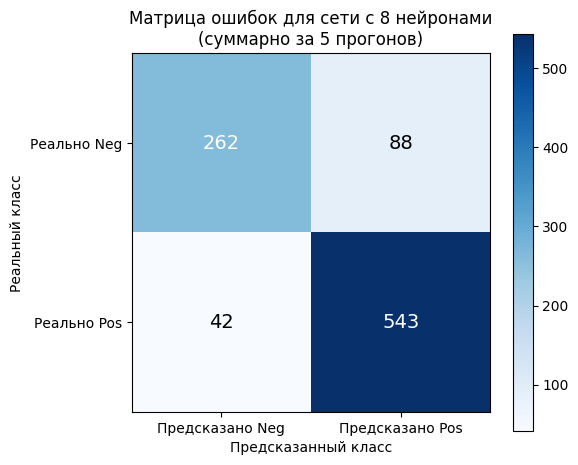

In [10]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[262, 88],   # [TN, FP]
               [42, 543]])  # [FN, TP]

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Матрица ошибок для сети с 8 нейронами\n(суммарно за 5 прогонов)')
plt.colorbar()

# Настройка меток
plt.xticks([0, 1], ['Предсказано Neg', 'Предсказано Pos'])
plt.yticks([0, 1], ['Реально Neg', 'Реально Pos'])

# Добавляем числа в ячейки
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > 200 else "black"
        plt.text(j, i, f'{cm[i, j]}',
                ha='center', va='center',
                color=color, fontsize=14)

plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()